# Pretrain/Finetune Similarity Signals

Analyze sweep similarity curves by layer and seed-comparison mode.

In [1]:
EXPERIMENT = "pretrain_finetune"
RUN_ID = None  # e.g. "pretrain_finetune_run_001"; None selects the newest run directory
METRICS_TO_PLOT = ["softmax_rwka", "rbf_rwka", "cka_rbf", "mutual_knn", "cknna"]
RWKA_SWEEP_METRICS = ["softmax_rwka", "rbf_rwka"]
PARAM_HEATMAP_METRICS = ["softmax_rwka", "rbf_rwka"]
CORRELATION_METRICS = [
    "softmax_rwka_var_weighted_auc",
    "softmax_rwka_auc",
    "rbf_rwka_var_weighted_auc",
    "rbf_rwka_auc",
    "CKA",
    "PWCCA",
    "Procrustes",
]
TASKS_TO_PLOT = None  # None uses every *_diff task column in full_df_self_computed.csv
CORRELATION_METHOD = "spearman"
CORRELATION_N_BOOT = 1000
CORRELATION_CI = 0.95
RANDOM_STATE = 0
REF_LAYER = None
SAMPLE_PARAM = 1.0


In [2]:
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

start = pathlib.Path.cwd().resolve()
for candidate in [start, *start.parents]:
    if (candidate / "paths.py").exists():
        REPO_DIR = candidate
        break
else:
    raise RuntimeError("Could not find repo root containing paths.py")

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from paths import resources_path
from experiments.sweep_analysis import (
    add_experiment_preset_columns,
    compute_pretrain_param_task_correlations,
    compute_task_metric_correlations,
    compute_variance_weighted_curve_auc,
    entries_to_dataframe,
    list_sweep_metrics,
    load_sweep_entries,
    merge_pretrain_weighted_sweep_features,
    plot_param_task_heatmap,
    plot_task_correlation_boxplot,
    plot_task_metric_bars,
    sample_similarity_at_param,
    save_preset_plots,
)

def latest_run(results_root):
    runs = [path for path in results_root.iterdir() if path.is_dir()]
    if not runs:
        raise FileNotFoundError(f"No run directories found under {results_root}")
    return max(runs, key=lambda path: path.stat().st_mtime)

def safe_name(value):
    return "".join(char if char.isalnum() or char in "._-" else "_" for char in str(value)).strip("_") or "plot"

results_root = resources_path / "results" / EXPERIMENT
results_path = results_root / RUN_ID if RUN_ID else latest_run(results_root)
sweeps_dir = results_path / "sweeps"
figures_dir = results_path / "figures" / "sweep_signals"
correlation_figures_dir = figures_dir / "task_correlations"
figures_dir.mkdir(parents=True, exist_ok=True)
correlation_figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Results path: {results_path}")
print(f"Sweeps path: {sweeps_dir}")
print(f"Figures path: {figures_dir}")
print(f"Correlation figures path: {correlation_figures_dir}")


Results path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001
Sweeps path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/sweeps
Figures path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals
Correlation figures path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/task_correlations


In [3]:
available_metrics = list_sweep_metrics(sweeps_dir)
metrics = [metric for metric in METRICS_TO_PLOT if metric in available_metrics]
if not metrics:
    metrics = available_metrics
print(f"Available sweep metrics: {available_metrics}")
print(f"Plotting metrics: {metrics}")

entries = load_sweep_entries(sweeps_dir)
sweep_df = entries_to_dataframe(entries)
sweep_df = add_experiment_preset_columns(sweep_df, EXPERIMENT, ref_layer=REF_LAYER)
print(sweep_df.shape)
print(sorted(sweep_df.columns))
sweep_df.head()

Available sweep metrics: ['cka_rbf', 'mutual_knn', 'rbf_rwka', 'softmax_rwka']
Plotting metrics: ['softmax_rwka', 'rbf_rwka', 'cka_rbf', 'mutual_knn']
(20172, 41)
['CKA', 'PWCCA', 'Procrustes', 'architecture1', 'architecture2', 'cka_rbf', 'cka_rbf_auc', 'cka_rbf_quantile', 'cknna', 'dataset1', 'dataset2', 'fineseed1', 'fineseed2', 'layer1', 'layer2', 'mean_cca_corr', 'mean_sq_cca_corr', 'metric', 'metric_auc', 'mutual_knn', 'mutual_knn_auc', 'param_name', 'param_values', 'path', 'preseed1', 'preseed2', 'pretrain_finetune_mode', 'rbf_rwka', 'rbf_rwka_auc', 'same_fineseed', 'same_model', 'same_preseed', 'same_seed', 'scores', 'seed1', 'seed2', 'seed_mode', 'softmax_rwka', 'softmax_rwka_auc', 'step1', 'step2']


,path,metric,metric_auc,param_name,param_values,scores,dataset1,architecture1,seed1,step1,...,same_seed,seed_mode,preseed1,preseed2,fineseed1,fineseed2,same_preseed,same_fineseed,same_model,pretrain_finetune_mode
0,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998034, 0.9999999999998038, 0.999...",mnli_matched_100,medium_finetuned,1,4,...,False,different_seed,1,10,4,10,False,False,False,different_model
1,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998046, 0.999999999999804, 0.9999...",mnli_matched_100,medium_finetuned,1,6,...,True,same_seed,1,1,6,10,True,False,False,same_preseed
2,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998039, 0.9999999999998037, 0.999...",mnli_matched_100,medium_finetuned,1,6,...,False,different_seed,1,2,6,5,False,False,False,different_model
3,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998043, 0.9999999999998043, 0.999...",mnli_matched_100,medium_finetuned,1,5,...,False,different_seed,1,3,5,10,False,False,False,different_model
4,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.01, 0.012389903709420908, 0.015350971392872...","[0.9999999999998043, 0.9999999999998039, 0.999...",mnli_matched_100,medium_finetuned,1,5,...,False,different_seed,1,4,5,10,False,False,False,different_model


Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_softmax_rwka_pretrain_finetune_modes_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_rbf_rwka_pretrain_finetune_modes_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_cka_rbf_pretrain_finetune_modes_by_layer.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_mutual_knn_pretrain_finetune_modes_by_layer.png


[PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_softmax_rwka_pretrain_finetune_modes_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_rbf_rwka_pretrain_finetune_modes_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_cka_rbf_pretrain_finetune_modes_by_layer.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/pretrain_finetune_mutual_knn_pretrain_finetune_modes_by_layer.png')]

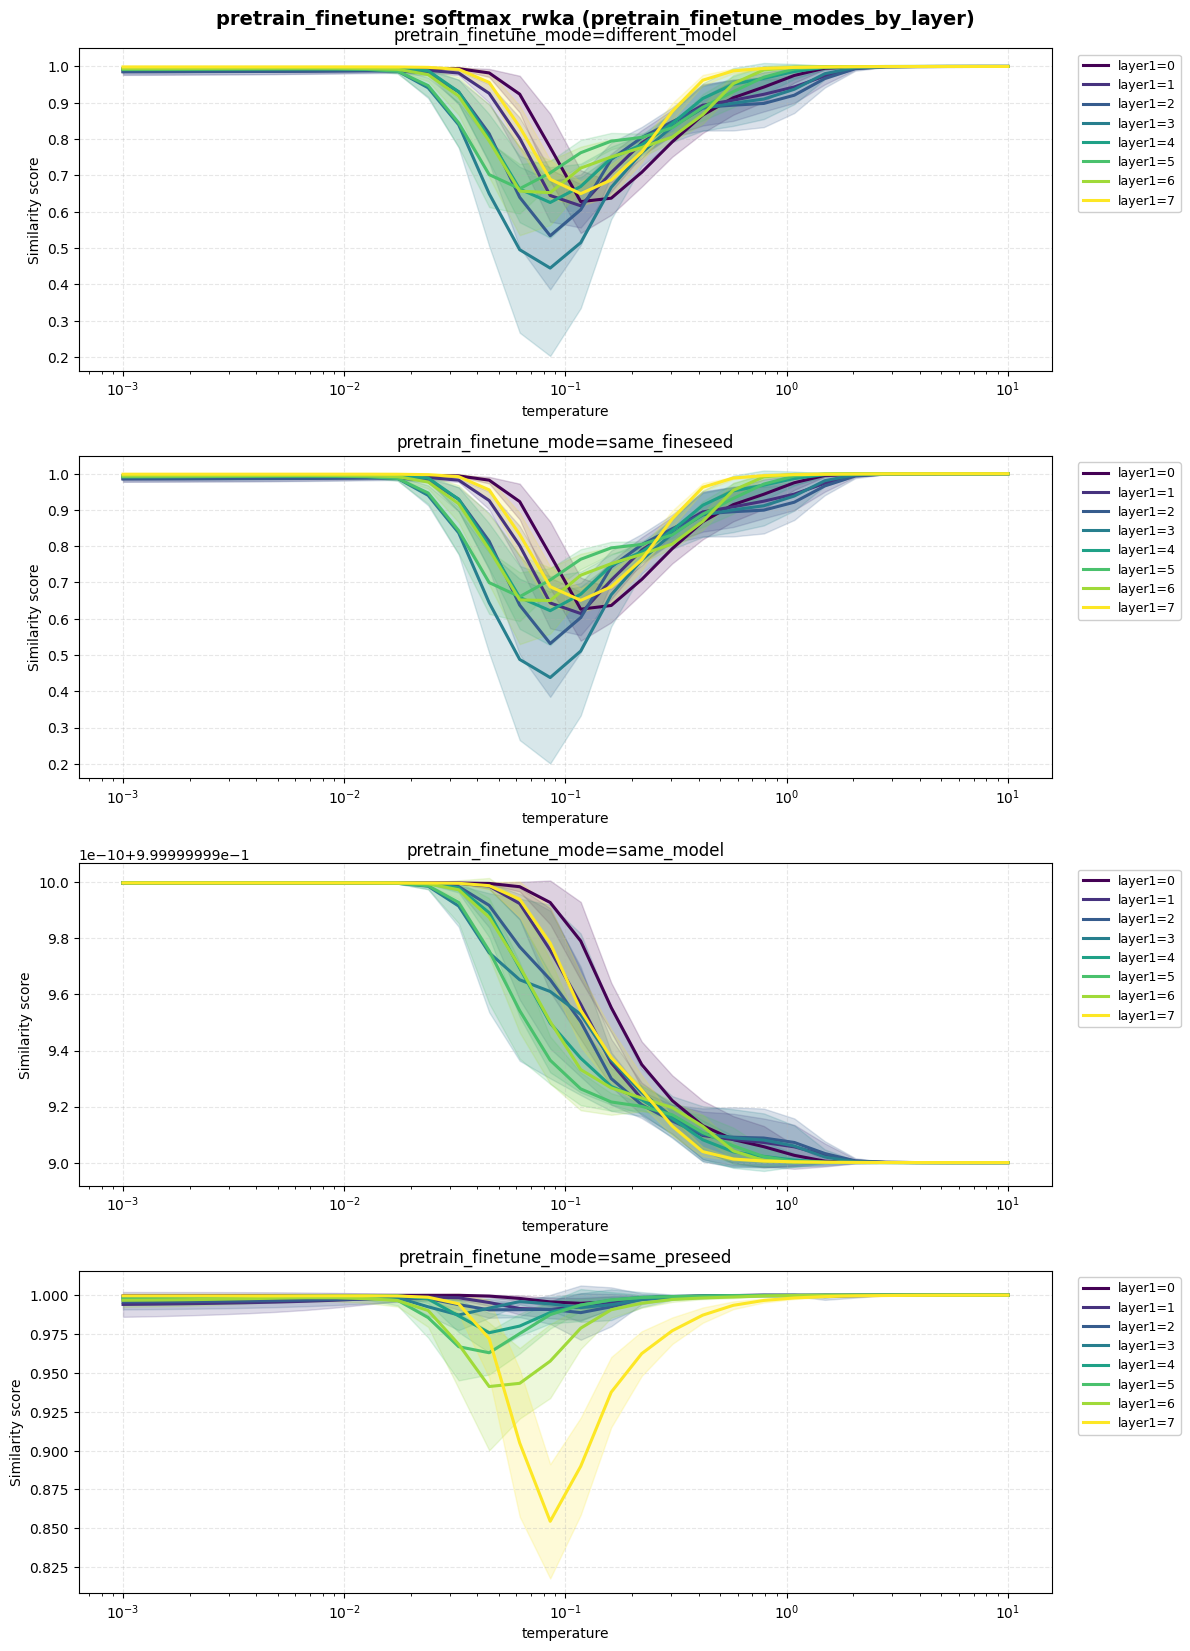

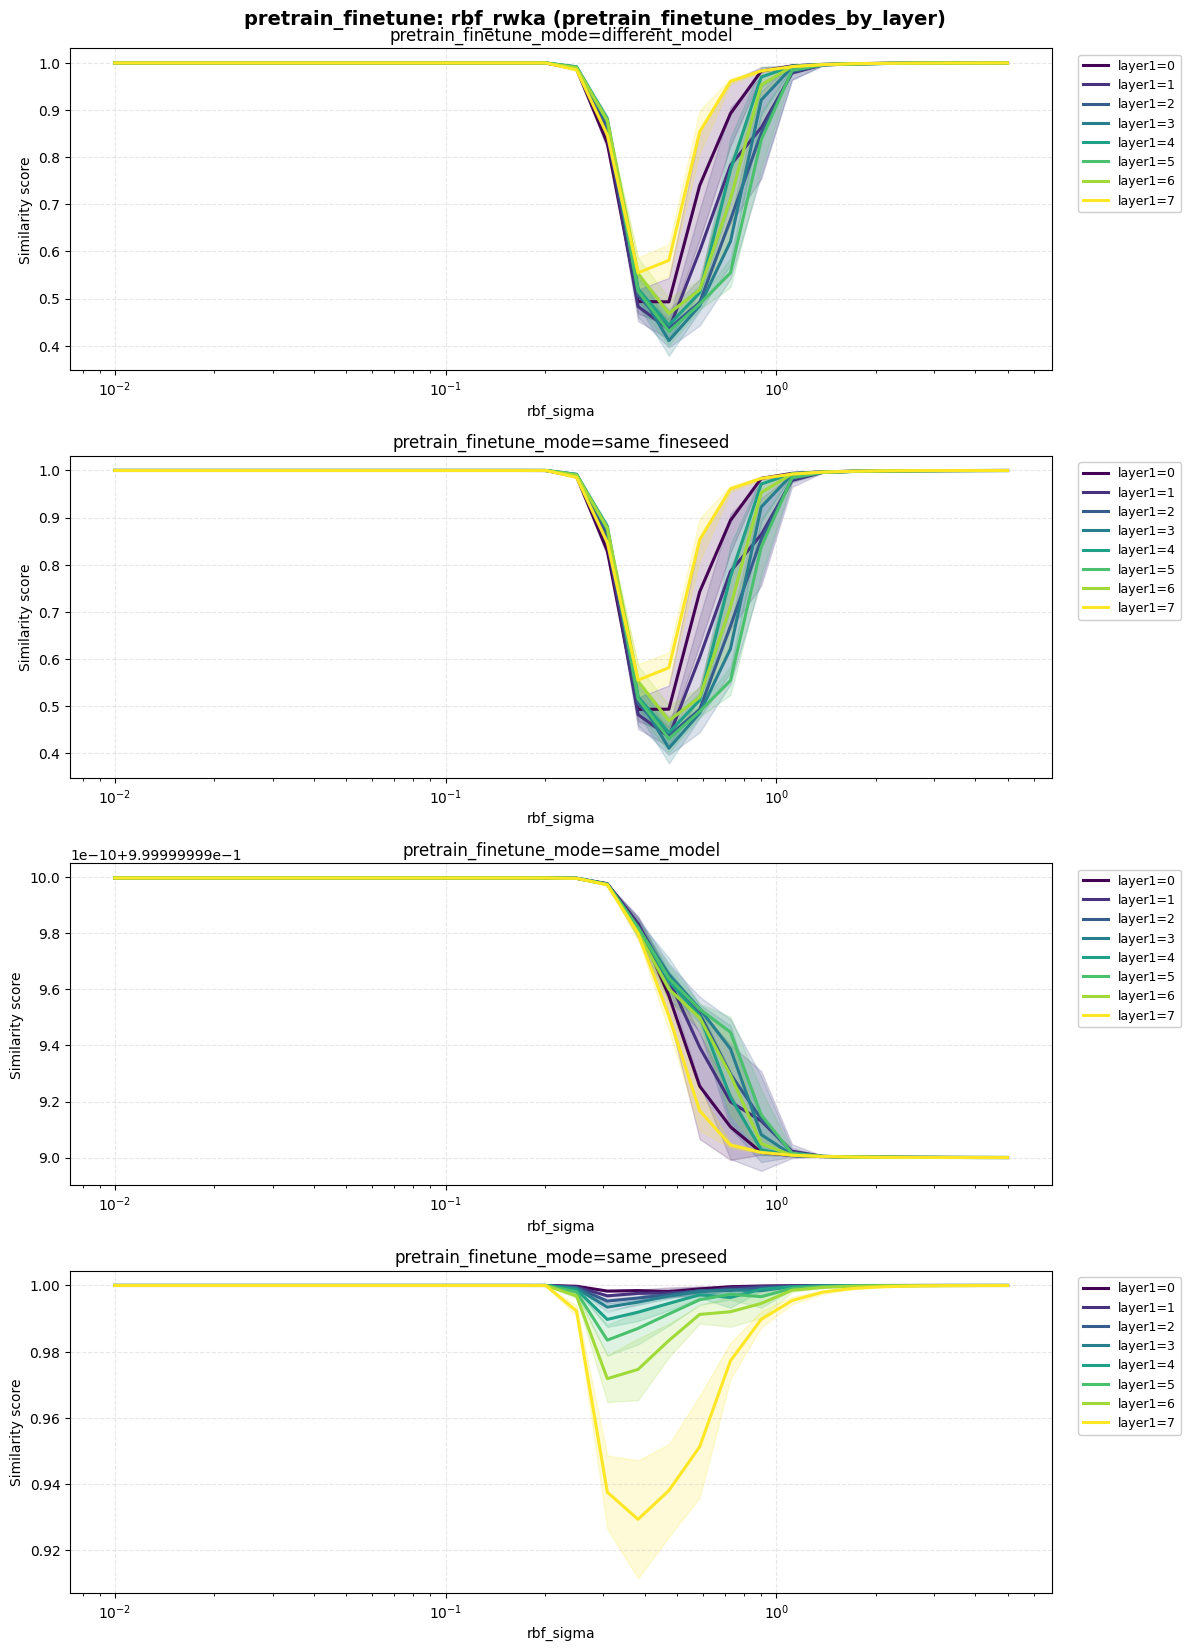

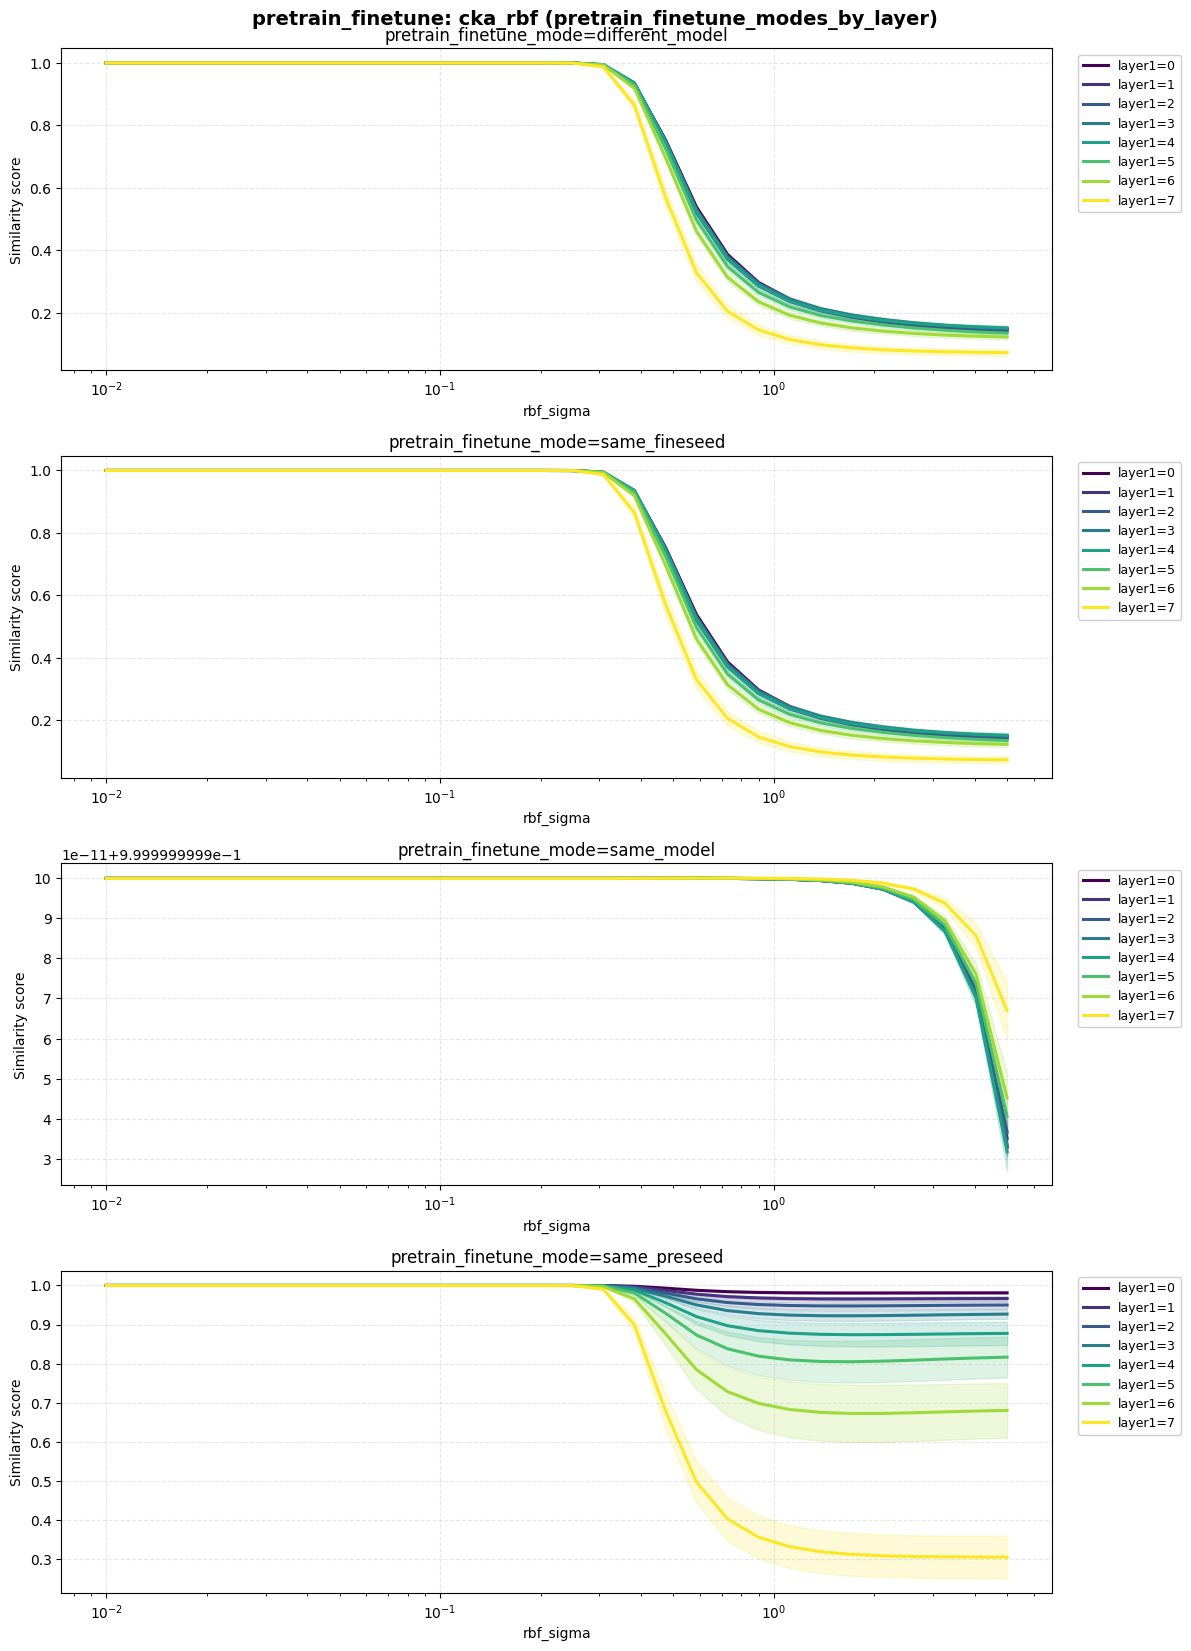

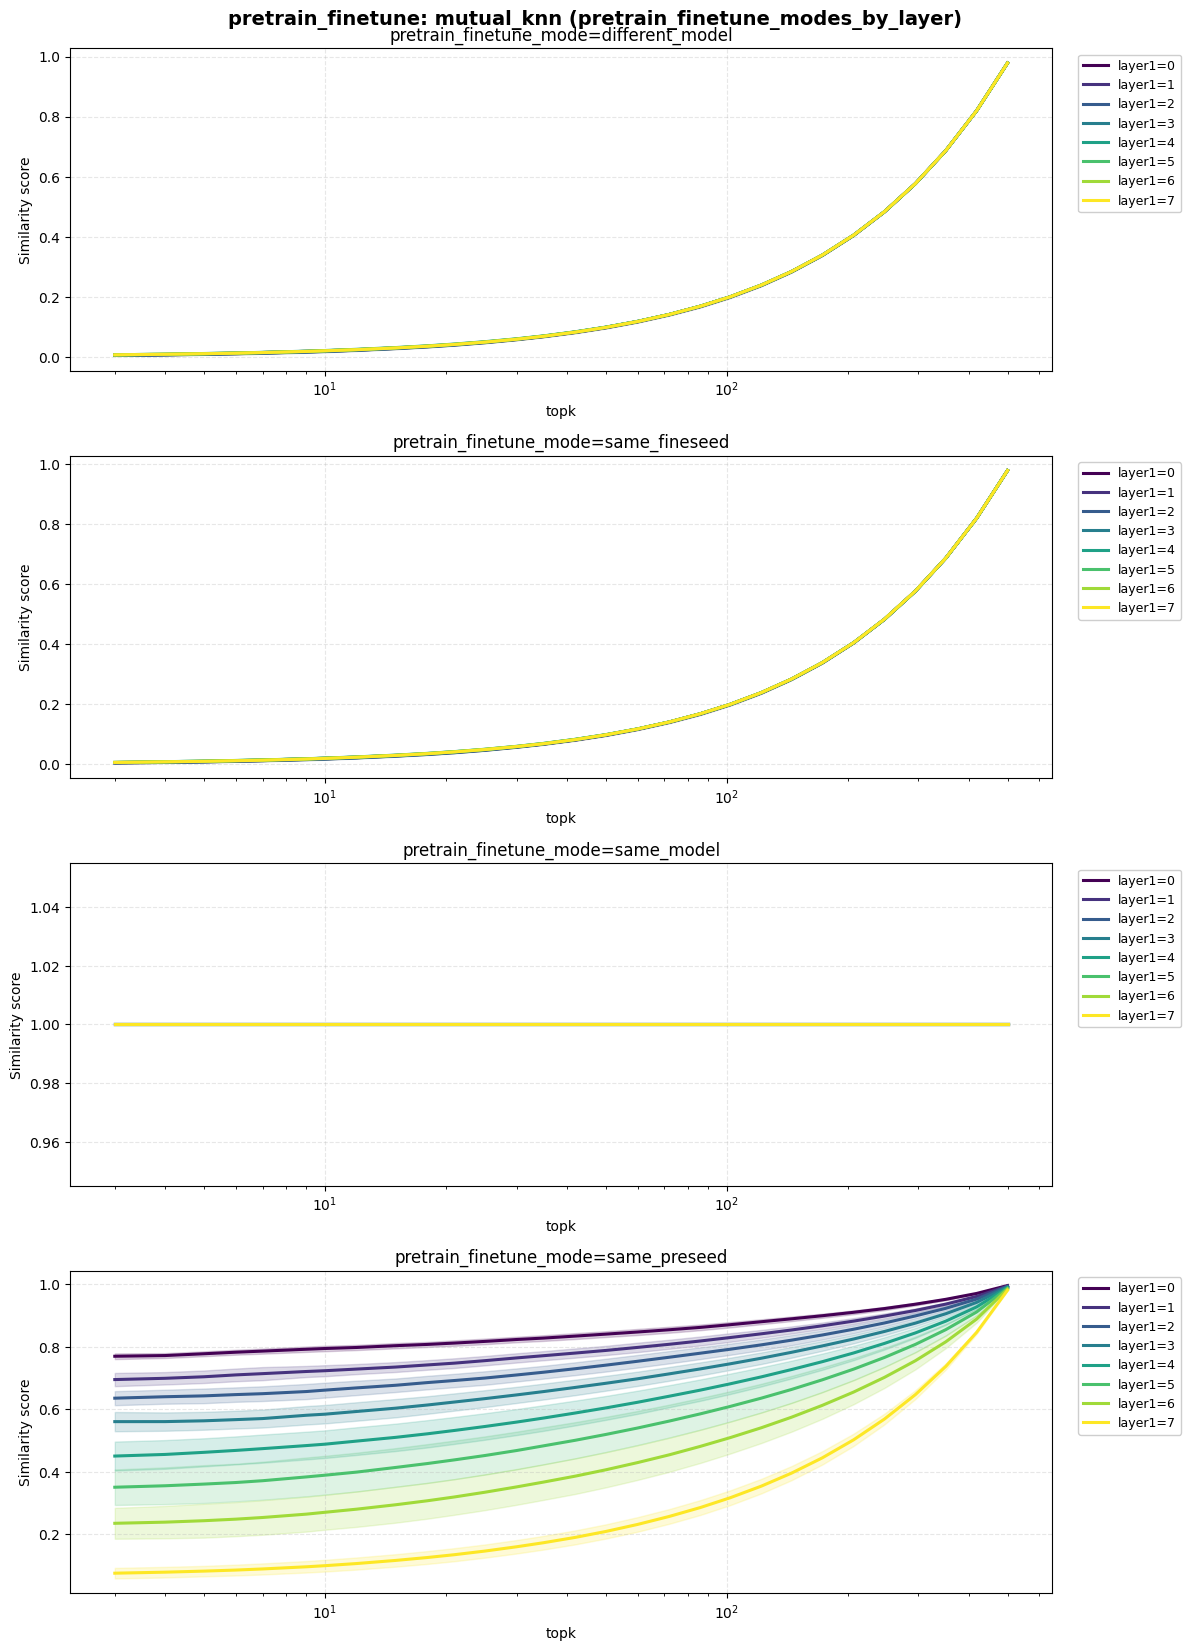

In [4]:
saved_paths = save_preset_plots(
    sweep_df,
    experiment=EXPERIMENT,
    metrics=metrics,
    figures_dir=figures_dir,
    ref_layer=REF_LAYER,
)
saved_paths

In [5]:
full_df_path = results_path / "full_df_self_computed.csv"
full_df = pd.read_csv(full_df_path)
print(f"Loaded full dataframe: {full_df.shape} from {full_df_path}")

weighted_feature_dfs = []
for metric in RWKA_SWEEP_METRICS:
    weighted_df = compute_variance_weighted_curve_auc(sweep_df, metric)
    if weighted_df.empty:
        print(f"No sweep rows found for {metric}")
        continue
    output_col = f"{metric}_var_weighted_auc"
    print(f"Built {output_col}: {weighted_df[output_col].notna().sum()} rows")
    weighted_feature_dfs.append(weighted_df)

analysis_df = merge_pretrain_weighted_sweep_features(full_df, weighted_feature_dfs)
available_corr_metrics = [metric for metric in CORRELATION_METRICS if metric in analysis_df.columns]
tasks = TASKS_TO_PLOT
if tasks is None:
    tasks = sorted(column.removesuffix("_diff") for column in analysis_df.columns if column.endswith("_diff"))

print(f"Correlation metrics: {available_corr_metrics}")
print(f"Correlation tasks: {tasks}")

corr_df = compute_task_metric_correlations(
    analysis_df,
    metrics=available_corr_metrics,
    tasks=tasks,
    method=CORRELATION_METHOD,
    n_boot=CORRELATION_N_BOOT,
    ci=CORRELATION_CI,
    random_state=RANDOM_STATE,
)

corr_csv_path = correlation_figures_dir / f"pretrain_finetune_{CORRELATION_METHOD}_task_metric_correlations.csv"
corr_df.to_csv(corr_csv_path, index=False)
print(f"Saved correlations to {corr_csv_path}")

boxplot_save_path = correlation_figures_dir / f"pretrain_finetune_{CORRELATION_METHOD}_task_correlation_boxplot.png"
boxplot_fig = plot_task_correlation_boxplot(
    corr_df,
    save_path=boxplot_save_path,
    title=f"pretrain_finetune: {CORRELATION_METHOD} task correlation distribution",
    metric_order=available_corr_metrics,
)
if boxplot_fig is not None:
    plt.close(boxplot_fig)

saved_corr_plots = []
for task in tasks:
    save_path = correlation_figures_dir / f"pretrain_finetune_{safe_name(task)}_{CORRELATION_METHOD}_metric_correlations.png"
    fig = plot_task_metric_bars(
        corr_df,
        task,
        save_path=save_path,
        metric_order=available_corr_metrics,
    )
    if fig is not None:
        saved_corr_plots.append(save_path)
        plt.close(fig)

print(f"Saved {len(saved_corr_plots)} task correlation plots")
corr_df.head(20)


Loaded full dataframe: (6560, 40) from /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/full_df_self_computed.csv
Built softmax_rwka_var_weighted_auc: 5043 rows
Built rbf_rwka_var_weighted_auc: 5043 rows
Correlation metrics: ['softmax_rwka_var_weighted_auc', 'softmax_rwka_auc', 'rbf_rwka_var_weighted_auc', 'rbf_rwka_auc', 'CKA', 'PWCCA', 'Procrustes']
Correlation tasks: ['BREAK', 'HANS', 'STRESS_ANTONYMY', 'STRESS_LENGTH', 'STRESS_NEGATION', 'STRESS_NUMERICAL', 'STRESS_OVERLAP', 'STRESS_SPELL', 'dev_matched', 'dev_mismatched', 'lex_nonent', 'snli_dev', 'snli_train', 'train']
Saved correlations to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/task_correlations/pretrain_finetune_spearman_task_metric_correlations.csv
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/fig

,task,task_col,metric,method,correlation,ci_low,ci_high,n
0,BREAK,BREAK_diff,softmax_rwka_var_weighted_auc,spearman,0.526809,0.506476,0.546557,4995
1,BREAK,BREAK_diff,softmax_rwka_auc,spearman,0.441128,0.421427,0.460412,6560
2,BREAK,BREAK_diff,rbf_rwka_var_weighted_auc,spearman,0.413544,0.390287,0.436273,4995
3,BREAK,BREAK_diff,rbf_rwka_auc,spearman,0.364529,0.343358,0.385330,6560
4,BREAK,BREAK_diff,CKA,spearman,0.251695,0.228889,0.274224,6560
5,BREAK,BREAK_diff,PWCCA,spearman,0.337214,0.315590,0.358488,6560
6,BREAK,BREAK_diff,Procrustes,spearman,0.312693,0.290693,0.334362,6560
7,HANS,HANS_diff,softmax_rwka_var_weighted_auc,spearman,0.262580,0.236570,0.288214,4995
8,HANS,HANS_diff,softmax_rwka_auc,spearman,0.215414,0.192216,0.238371,6560
9,HANS,HANS_diff,rbf_rwka_var_weighted_auc,spearman,0.234780,0.208403,0.260815,4995


In [6]:
param_corr_dfs = []
for metric in PARAM_HEATMAP_METRICS:
    param_corr_df = compute_pretrain_param_task_correlations(
        full_df,
        sweep_df,
        metric_name=metric,
        tasks=tasks,
        method=CORRELATION_METHOD,
        n_boot=0,
        ci=CORRELATION_CI,
        random_state=RANDOM_STATE,
    )
    if param_corr_df.empty:
        print(f"No parameter correlations found for {metric}")
        continue
    param_corr_dfs.append(param_corr_df)

if param_corr_dfs:
    all_param_corr_df = pd.concat(param_corr_dfs, ignore_index=True)
    param_corr_csv_path = correlation_figures_dir / f"pretrain_finetune_{CORRELATION_METHOD}_param_task_correlations.csv"
    all_param_corr_df.to_csv(param_corr_csv_path, index=False)
    print(f"Saved parameter correlations to {param_corr_csv_path}")

    saved_heatmaps = []
    for metric in PARAM_HEATMAP_METRICS:
        save_path = correlation_figures_dir / f"pretrain_finetune_{safe_name(metric)}_{CORRELATION_METHOD}_param_task_heatmap.png"
        fig = plot_param_task_heatmap(
            all_param_corr_df,
            metric_name=metric,
            save_path=save_path,
            title=f"{metric}: task correlation by sweep parameter",
        )
        if fig is not None:
            saved_heatmaps.append(save_path)
            plt.close(fig)
    print(f"Saved {len(saved_heatmaps)} parameter heatmaps")
    display(all_param_corr_df.head(20))
else:
    print("No parameter correlation heatmaps were created")


Saved parameter correlations to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/task_correlations/pretrain_finetune_spearman_param_task_correlations.csv
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/task_correlations/pretrain_finetune_softmax_rwka_spearman_param_task_heatmap.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pretrain_finetune/pretrain_finetune_run_001/figures/sweep_signals/task_correlations/pretrain_finetune_rbf_rwka_spearman_param_task_heatmap.png
Saved 2 parameter heatmaps


,task,task_col,metric,method,correlation,ci_low,ci_high,n,param_idx,param_value
0,BREAK,BREAK_diff,softmax_rwka,spearman,0.356443,0.331992,0.380416,4995,0,0.001000
1,HANS,HANS_diff,softmax_rwka,spearman,0.199501,0.172723,0.225984,4995,0,0.001000
2,STRESS_ANTONYMY,STRESS_ANTONYMY_diff,softmax_rwka,spearman,0.371237,0.347077,0.394905,4995,0,0.001000
3,STRESS_LENGTH,STRESS_LENGTH_diff,softmax_rwka,spearman,0.165298,0.138198,0.192150,4995,0,0.001000
4,STRESS_NEGATION,STRESS_NEGATION_diff,softmax_rwka,spearman,0.297222,0.271729,0.322298,4995,0,0.001000
5,STRESS_NUMERICAL,STRESS_NUMERICAL_diff,softmax_rwka,spearman,0.123755,0.096352,0.150970,4995,0,0.001000
6,STRESS_OVERLAP,STRESS_OVERLAP_diff,softmax_rwka,spearman,0.170394,0.143338,0.197195,4995,0,0.001000
7,STRESS_SPELL,STRESS_SPELL_diff,softmax_rwka,spearman,0.235199,0.208828,0.261228,4995,0,0.001000
8,dev_matched,dev_matched_diff,softmax_rwka,spearman,0.258076,0.232003,0.283778,4995,0,0.001000
9,dev_mismatched,dev_mismatched_diff,softmax_rwka,spearman,0.176620,0.149620,0.203357,4995,0,0.001000
